In [33]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

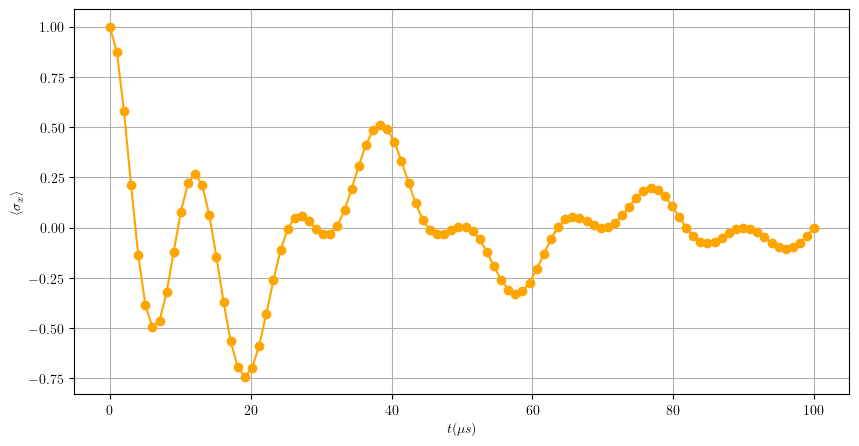

In [24]:
zeta = [2 * jnp.pi * 5 * 10 ** 4, 2 * jnp.pi * 5 * 10 ** 4, 2 * jnp.pi * 5.5 * 10 ** 4]

t = jnp.linspace(0, 100 * 1e-6, 100)
mj = 1 - (1 - jnp.exp(-t / (25 * 1e-6)))

sigma_xt = jnp.ones_like(t)

for j in range(len(zeta)):
    sigma_xt *= (jnp.cos(zeta[j] * t / 2) + 1j * mj * jnp.sin(zeta[j] * t / 2)) 

sigma_xt = jnp.real(sigma_xt)
sigma_xt *= jnp.exp(-t / (70 * 1e-6))

fig = plt.figure(figsize=(10, 5))

plt.plot(t * 1e6, sigma_xt, color='orange', marker='o')
plt.xlabel('$t (\\mu s)$')
plt.ylabel('$\\langle \\sigma_x \\rangle$')
plt.grid()
plt.show()


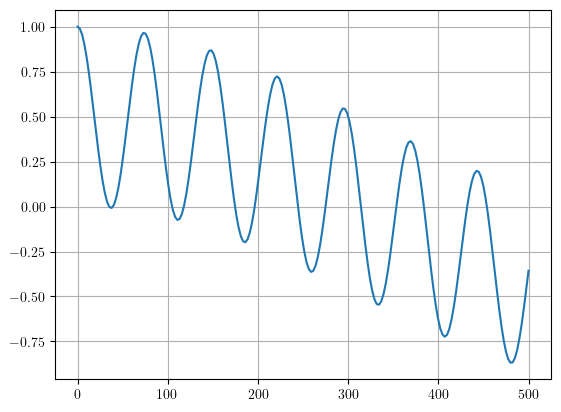

In [32]:
t = jnp.linspace(0, 500, 200)



fx = jnp.cos(4 / 100 * t) * jnp.cos(4.5 / 100 * t)

plt.plot(t, fx)
plt.grid()
plt.show()

In [37]:
file = "results/state_tomography/crosstalk/ibm_strasbourg/init-,+,+,+/bloch-q[64, 63, 65, 54]-np50-gpp50-s8192-2025-04-28T23-14-04.csv"

with open(file, 'r') as f:
    df = pd.read_csv(file)

print(df)

     t_us    X_mean    Y_mean    Z_mean     X_std     Y_std     Z_std
0     0.0 -0.980713 -0.030029  0.006104  0.002159  0.011044  0.011048
1     3.0 -0.804932  0.136963  0.025879  0.006556  0.010944  0.011045
2     6.0 -0.796631  0.242676  0.070557  0.006678  0.010718  0.011021
3     9.0 -0.617188  0.338379  0.114502  0.008693  0.010397  0.010976
4    12.0 -0.546631  0.421631  0.173340  0.009252  0.010018  0.010881
5    15.0 -0.321289  0.400391  0.240234  0.010463  0.010124  0.010725
6    18.0 -0.220703  0.425537  0.233887  0.010776  0.009998  0.010742
7    21.0 -0.051270  0.362061  0.272217  0.011034  0.010299  0.010631
8    24.0  0.024902  0.302979  0.264893  0.011045  0.010529  0.010654
9    27.0  0.060059  0.192871  0.278564  0.011029  0.010841  0.010611
10   30.0  0.080322  0.121094  0.274414  0.011013  0.010967  0.010624
11   33.0  0.045898  0.012695  0.305664  0.011037  0.011048  0.010520
12   36.0 -0.020752 -0.082275  0.320312  0.011046  0.011011  0.010466
13   39.0 -0.104492 

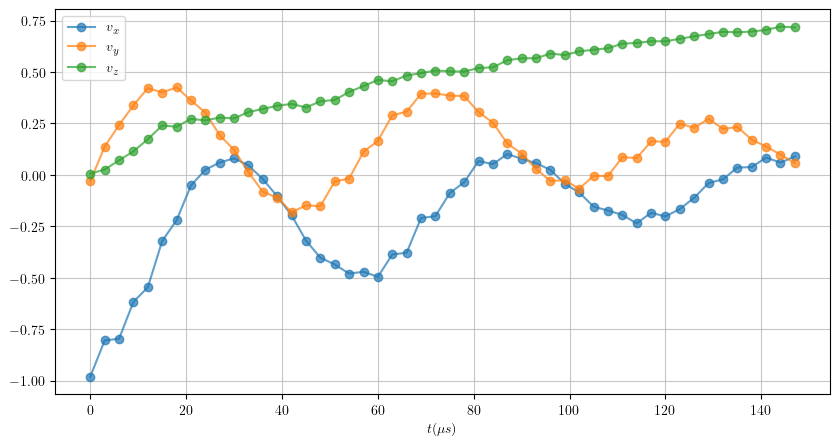

In [44]:
t_us = df['t_us']
vx, vy, vz = df['X_mean'], df['Y_mean'], df['Z_mean']

fig = plt.figure(figsize=(10, 5))

plt.plot(t_us, vx, 'o-', label='$v_x$', alpha=0.7)
plt.plot(t_us, vy, 'o-', label='$v_y$', alpha=0.7)
plt.plot(t_us, vz, 'o-', label='$v_z$', alpha=0.7)
# plt.plot(t_us, vx**2 + vy **2 + vz ** 2, 'o-', alpha=0.7, label="Tr$\\rho^2$")
plt.legend(loc='best')
plt.grid(alpha=0.7)
plt.xlabel('$t(\\mu s)$')
plt.show()
